# γ² Fidelity Estimator: Universality Test (90/10 Train/Test)

## What this notebook tests

The corrected bound $R = \alpha(\gamma^2, M)\cdot\gamma^2$ is calibrated on data.
The key question is whether it acts as a **universal** lower bound, or whether it
simply memorises the training circuits.

**Three experiments:**

| Test                     | Train              | Test              | Answers                                                  |
| ------------------------ | ------------------ | ----------------- | -------------------------------------------------------- |
| **Random 90/10**         | 90% of trials      | 10% of trials     | Does it hold on unseen draws from the same distribution? |
| **Leave-one-family-out** | 3 circuit families | 1 held-out family | Does it hold on an entirely unseen circuit type?         |
| **Leave-one-N-out**      | $N\in\{14,16,18\}$ | $N=20$            | Does it extrapolate to unseen system sizes?              |

A calibration is **universal** if test violation rates match training rates
within sampling noise (Wilson CI overlap). A systematically higher test
violation rate indicates overfitting.


In [42]:
import numpy as np, json, sys
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from scipy.optimize import differential_evolution, minimize
from scipy import stats as sci_stats
import math


def find_repo_root(start=None):
    p = Path.cwd() if start is None else Path(start).resolve()
    for c in (p, *p.parents):
        if (c / "src").is_dir() and (c / "requirements.txt").exists():
            return c
    raise RuntimeError("Repo root not found")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

THIS_DIR = REPO_ROOT / "tests"
FIGURE_DIR = THIS_DIR / "figures"
DATA_DIR = THIS_DIR / "results"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

from src.experimentation.runner import (
    exact_statevector,
    fidelity_bass,
    make_haar,
    make_brickwork,
    make_qaoa,
    make_tfim,
)
from src.simulation.bass_simulator import BASS
from src.visualization.style import mplstyle, polish_axes, save_figure

mplstyle(dpi=180)
mpl.rcParams.update(
    {
        "font.size": 8.0,
        "axes.labelsize": 8.0,
        "xtick.labelsize": 7.0,
        "ytick.labelsize": 7.0,
        "legend.fontsize": 6.8,
        "lines.linewidth": 1.1,
        "lines.markersize": 2.8,
        "axes.linewidth": 0.8,
    }
)

In [25]:
N_VALUES = [14, 16, 18, 20]
K_VALUES = [512, 1024, 2048, 4096]
N_TRIALS = 50  # per (family, N, k) cell → 50 × 64 = 3200 records total
SEED_BASE = 42
SPLIT_SEED = 2026  # separate seed for the train/test split
FORCE_RERUN = False
BASS_KW = {"use_2qubit_rotations": True}

# Correction-bound hyperparameter search domain
PARAM_BOUNDS = [(0.1, 2.0), (0.5, 10.0), (0.5, 4.0)]  # z  # eta  # delta

NOISE_FLOOR = 1e-6  # |γ²-F| < NOISE_FLOOR → floating-point noise, not a real violation
REL_TOL = 1e-3  # relative tolerance: (γ²-F)/γ² < REL_TOL → not a real violation


def get_families(N):
    return [
        {
            "key": "haar",
            "label": "Haar L=3",
            "color": "#E87722",
            "factory": lambda rng: make_haar(N, depth=3, rng=rng),
        },
        {
            "key": "brickwork",
            "label": "Brickwork L=5",
            "color": "#0C5DA5",
            "factory": lambda rng: make_brickwork(N, depth=5, rng=rng),
        },
        {
            "key": "qaoa",
            "label": "QAOA p=3",
            "color": "#B3446C",
            "factory": lambda rng: make_qaoa(N, rounds=3, rng=rng),
        }
    ]


FAMILY_LABELS = [f["label"] for f in get_families(14)]
FAMILY_COLORS = {f["label"]: f["color"] for f in get_families(14)}

print(
    f"Total records: {N_TRIALS} × {len(FAMILY_LABELS)} fam × {len(N_VALUES)} N × {len(K_VALUES)} k "
    f"= {N_TRIALS*len(FAMILY_LABELS)*len(N_VALUES)*len(K_VALUES):,}"
)
print(
    f"90/10 split → {int(0.9*N_TRIALS)} train trials, {N_TRIALS-int(0.9*N_TRIALS)} test trials per cell"
)

Total records: 50 × 3 fam × 4 N × 4 k = 2,400
90/10 split → 45 train trials, 5 test trials per cell


In [26]:
_npz = DATA_DIR / "gamma_diagnostics.npz"
_meta = DATA_DIR / "gamma_diagnostics_meta.json"
_expected = {
    "N_values": N_VALUES,
    "K_values": K_VALUES,
    "n_trials": N_TRIALS,
    "seed_base": SEED_BASE,
    "bass_kw": BASS_KW,
}


def collect_data():
    nF, nN, nK, nT = len(get_families(14)), len(N_VALUES), len(K_VALUES), N_TRIALS
    gamma_sq = np.full((nF, nN, nK, nT), np.nan)
    true_f = np.full((nF, nN, nK, nT), np.nan)
    gate_count = np.zeros((nF, nN), dtype=int)

    for ni, N in enumerate(N_VALUES):
        families = get_families(N)
        for fi, fam in enumerate(families):
            print(f"  [{fam['label']}] N={N}")
            for t in range(nT):
                seed = SEED_BASE * 10**6 + ni * 1000 + fi * 100 + t
                rng = np.random.default_rng(seed)
                circ = fam["factory"](rng)
                gate_count[fi, ni] = len(circ)
                exact_sv = exact_statevector(N, circ)
                for ki, K in enumerate(K_VALUES):
                    sim = BASS(N, K, **BASS_KW)
                    state = sim.simulate(circ)
                    gamma_sq[fi, ni, ki, t] = float(state.gamma**2)
                    true_f[fi, ni, ki, t] = fidelity_bass(sim, state, exact_sv)

    return {"gamma_sq": gamma_sq, "true_f": true_f, "gate_count": gate_count}


if _npz.exists() and _meta.exists() and not FORCE_RERUN:
    stored = json.loads(_meta.read_text())
    if stored == _expected:
        print(f"Loading cache: {_npz}")
        raw = dict(np.load(_npz, allow_pickle=False))
    else:
        print("Metadata mismatch — recomputing")
        raw = collect_data()
        np.savez_compressed(_npz, **raw)
        _meta.write_text(json.dumps(_expected, indent=2))
else:
    raw = collect_data()
    np.savez_compressed(_npz, **raw)
    _meta.write_text(json.dumps(_expected, indent=2))

gamma_sq = raw["gamma_sq"]  # (nF, nN, nK, nT)
true_f = raw["true_f"]
gate_count = raw["gate_count"]
print(
    f"Data shape: {gamma_sq.shape}  →  "
    f"{np.sum(np.isfinite(gamma_sq)):,} valid records"
)

Loading cache: c:\Users\karti\pyth\BASS code\tests\results\gamma_diagnostics.npz
Data shape: (4, 4, 4, 50)  →  3,200 valid records


In [43]:
# ── Helpers shared across all experiments ─────────────────────────────────────


def is_violation(gsq, f):
    """True iff F < γ² by more than numerical noise."""
    if f >= gsq:
        return False
    delta = gsq - f
    return (delta >= NOISE_FLOOR) and (delta / max(gsq, 1e-15) >= REL_TOL)


def corrected_bound(gsq, M, z, eta, delta):
    """Corrected lower bound R = α(γ², M) · γ²."""
    gsq = max(float(gsq), 1e-15)
    alphaA = 1.0 - z * np.sqrt((1.0 - gsq) / (gsq * eta * M))
    alphaB = 1.0 - (gsq / (M**delta))
    alpha = float(np.clip(min(alphaA, alphaB), 0.01, 1.0))
    return alpha * gsq


def binom_ci(k, n, ci=0.95):
    """Wilson score CI for a binomial proportion."""
    if n == 0:
        return np.nan, np.nan
    z = sci_stats.norm.ppf(0.5 + ci / 2)
    p = k / n
    d = 1 + z**2 / n
    ct = (p + z**2 / (2 * n)) / d
    mg = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return float(max(0, ct - mg)), float(min(1, ct + mg))


# Flatten raw arrays into a list of records for flexible subsetting
families_14 = get_families(14)
all_records = []
for fi, fam in enumerate(families_14):
    for ni, N in enumerate(N_VALUES):
        for ki, K in enumerate(K_VALUES):
            M = int(gate_count[fi, ni])
            for t in range(N_TRIALS):
                g = gamma_sq[fi, ni, ki, t]
                f = true_f[fi, ni, ki, t]
                if np.isfinite(g) and np.isfinite(f):
                    all_records.append(
                        dict(
                            family=fam["label"],
                            fi=fi,
                            ni=ni,
                            ki=ki,
                            N=N,
                            K=K,
                            M=M,
                            trial=t,
                            gsq=g,
                            true_f=f,
                        )
                    )

print(f"Flat record count: {len(all_records):,}")
print(
    f"Raw γ² violations: "
    f"{sum(is_violation(r['gsq'],r['true_f']) for r in all_records):,} "
    f"/ {len(all_records):,} "
    f"({100*sum(is_violation(r['gsq'],r['true_f']) for r in all_records)/len(all_records):.1f}%)"
)

# ── Calibration helpers ───────────────────────────────────────────────────────


def make_loss(records):
    """
    Asymmetric calibration loss on a set of records.
    Heavy quadratic penalty for violations (R > F),
    light linear reward for tighter safe bounds (R < F).
    """

    def _loss(params):
        z, eta, delta = params
        total = 0.0
        for r in records:
            R = corrected_bound(r["gsq"], r["M"], z, eta, delta)
            err = R - r["true_f"]
            if err > 0 and is_violation(R, r["true_f"]):
                total += 1e4 * err**2  # violation: heavy penalty
            else:
                total += max(0.0, -err)  # safe: reward tightness
        return total

    return _loss


def calibrate_de(records, seed=42):
    """Global calibration via Differential Evolution (slow, thorough)."""
    result = differential_evolution(
        make_loss(records),
        PARAM_BOUNDS,
        seed=seed,
        maxiter=300,
        tol=1e-4,
        popsize=12,
        workers=1,
    )
    return result.x, result.fun


def calibrate_local(records, x0):
    """Local calibration from initial point (fast, for CV folds)."""
    result = minimize(
        make_loss(records),
        x0,
        method="Nelder-Mead",
        options={"maxiter": 8000, "xatol": 1e-5, "fatol": 1e-3},
    )
    return result.x, result.fun


def eval_violations(records, z, eta, delta):
    """Violation stats for a record set under given parameters."""
    n = len(records)
    v = sum(
        1
        for r in records
        if is_violation(corrected_bound(r["gsq"], r["M"], z, eta, delta), r["true_f"])
    )
    rate = v / n if n > 0 else np.nan
    lo, hi = binom_ci(v, n)
    return dict(
        viol=v, n=n, rate=rate,
        ci_lo=lo, ci_hi=hi,
        pct=100 * rate, pct_lo=100 * lo, pct_hi=100 * hi,
    )


def fmt_viol(ev, label=""):
    # Updated slightly to handle the NaNs for the raw bounds gracefully
    pct_lo_str = f"{ev['pct_lo']:.2f}%" if not math.isnan(ev.get('pct_lo', float('nan'))) else "N/A"
    pct_hi_str = f"{ev['pct_hi']:.2f}%" if not math.isnan(ev.get('pct_hi', float('nan'))) else "N/A"
    
    return (
        f"{label:<30} {ev['viol']:>4}/{ev['n']:<5} "
        f"{ev['pct']:>6.2f}%  [{pct_lo_str}, {pct_hi_str}]"
    )

Flat record count: 2,400
Raw γ² violations: 51 / 2,400 (2.1%)


In [28]:
# ── Raw γ² violation baseline (no correction) ─────────────────────────────────
print("=" * 75)
print("RAW γ² VIOLATION RATES  (F < γ² by more than noise floor)")
print("=" * 75)
hdr = f"{'Family':<18} {'N':>4} {'k':>6}  {'Viol/n':>10}  {'Rate%':>7}  Wilson 95% CI"
print(hdr)
print("-" * 75)

for fi, fam in enumerate(families_14):
    for ni, N in enumerate(N_VALUES):
        for ki, K in enumerate(K_VALUES):
            recs = [
                r
                for r in all_records
                if r["fi"] == fi and r["ni"] == ni and r["ki"] == ki
            ]
            v = sum(is_violation(r["gsq"], r["true_f"]) for r in recs)
            n = len(recs)
            lo, hi = binom_ci(v, n)
            print(
                f"{fam['label']:<18} {N:>4} {K:>6}  "
                f"{v:>4}/{n:<5}  {100*v/n:>6.2f}%  "
                f"[{100*lo:.2f}%, {100*hi:.2f}%]"
            )

raw_total_v = sum(is_violation(r["gsq"], r["true_f"]) for r in all_records)
raw_total_n = len(all_records)
print(f"\nGlobal raw: {raw_total_v}/{raw_total_n} = {100*raw_total_v/raw_total_n:.2f}%")
print("=" * 75)

RAW γ² VIOLATION RATES  (F < γ² by more than noise floor)
Family                N      k      Viol/n    Rate%  Wilson 95% CI
---------------------------------------------------------------------------
Haar L=3             14    512     0/50       0.00%  [0.00%, 7.13%]
Haar L=3             14   1024     0/50       0.00%  [0.00%, 7.13%]
Haar L=3             14   2048     0/50       0.00%  [0.00%, 7.13%]
Haar L=3             14   4096     1/50       2.00%  [0.35%, 10.50%]
Haar L=3             16    512     3/50       6.00%  [2.06%, 16.22%]
Haar L=3             16   1024     1/50       2.00%  [0.35%, 10.50%]
Haar L=3             16   2048     1/50       2.00%  [0.35%, 10.50%]
Haar L=3             16   4096     0/50       0.00%  [0.00%, 7.13%]
Haar L=3             18    512     1/50       2.00%  [0.35%, 10.50%]
Haar L=3             18   1024     1/50       2.00%  [0.35%, 10.50%]
Haar L=3             18   2048     1/50       2.00%  [0.35%, 10.50%]
Haar L=3             18   4096     1/50     

In [44]:
# ── Experiment 1: Random 90/10 trial-level split ──────────────────────────────
#
# Split by trial index: the SAME trial indices go into train or test across
# ALL (family, N, k) cells.  This prevents data leakage — different (N, k)
# views of the same circuit instance cannot appear in both sets.

split_rng = np.random.default_rng(SPLIT_SEED)
trial_perm = split_rng.permutation(N_TRIALS)
n_train = int(0.9 * N_TRIALS)  # 45 trials per cell
train_trials = set(trial_perm[:n_train].tolist())
test_trials = set(trial_perm[n_train:].tolist())

train_recs = [r for r in all_records if r["trial"] in train_trials]
test_recs = [r for r in all_records if r["trial"] in test_trials]

print(
    f"Split (seed={SPLIT_SEED}): {len(train_recs):,} train / {len(test_recs):,} test records"
)
print(f"  train trials: {sorted(train_trials)[:10]}... ({len(train_trials)} total)")
print(f"  test  trials: {sorted(test_trials)}")

# ── Global calibration on TRAINING set only ──────────────────────────────────
print("\nCalibrating on training set (Differential Evolution, may take ~30s)...")
(z_opt, eta_opt, delta_opt), loss_val = calibrate_de(train_recs, seed=42)
print(f"  z={z_opt:.4f}  eta={eta_opt:.4f}  delta={delta_opt:.4f}  loss={loss_val:.2f}")

# ── Evaluate on BOTH sets ─────────────────────────────────────────────────────
raw_v_train = sum(1 for r in train_recs if is_violation(r['gsq'], r['true_f']))
raw_v_test  = sum(1 for r in test_recs  if is_violation(r['gsq'], r['true_f']))
ev_corr_train = eval_violations(train_recs, z_opt, eta_opt, delta_opt)
ev_corr_test = eval_violations(test_recs, z_opt, eta_opt, delta_opt)

print("\n" + "=" * 75)
print(
    f"EXPERIMENT 1: Random 90/10 split  "
    f"(train={len(train_recs):,} / test={len(test_recs):,} records)"
)
print("=" * 75)
hdr3 = f"{'Set':<30} {'Viol/n':>8}  {'Rate%':>7}  [Wilson 95% CI]"

# Helper dictionary to format raw integers into the structure expected by fmt_viol
def make_raw_dict(viol, n):
    pct = (viol / n) * 100 if n > 0 else 0.0
    return {'viol': viol, 'n': n, 'pct': pct, 'pct_lo': float('nan'), 'pct_hi': float('nan')}

print(f"RAW γ² (no correction):")
print(hdr3)
print(fmt_viol(make_raw_dict(raw_v_train, len(train_recs)), "  Train"))
print(fmt_viol(make_raw_dict(raw_v_test, len(test_recs)), "  Test"))

print(f"\nCORRECTED bound (z={z_opt:.3f}, η={eta_opt:.3f}, δ={delta_opt:.3f}):")
print(hdr3)
print(fmt_viol(ev_corr_train, "  Train (calibrated on)"))
print(fmt_viol(ev_corr_test, "  Test  (held-out)"))

# Quantify overfitting: is test significantly worse?
gap_pct = ev_corr_test["pct"] - ev_corr_train["pct"]
print(f"\nTrain→Test violation gap: {gap_pct:+.2f} pp")
if ev_corr_test["ci_lo"] * 100 <= ev_corr_train["pct"]:
    print("  → CIs OVERLAP: no statistically significant generalisation failure.")
else:
    print("  → CIs DO NOT OVERLAP: bound is overfit (worse on held-out trials).")
print("=" * 75)

Split (seed=2026): 2,160 train / 240 test records
  train trials: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10]... (45 total)
  test  trials: [4, 37, 39, 42, 49]

Calibrating on training set (Differential Evolution, may take ~30s)...
  z=0.1039  eta=9.0686  delta=3.8067  loss=111.46

EXPERIMENT 1: Random 90/10 split  (train=2,160 / test=240 records)
RAW γ² (no correction):
Set                              Viol/n    Rate%  [Wilson 95% CI]
  Train                          46/2160    2.13%  [N/A, N/A]
  Test                            5/240     2.08%  [N/A, N/A]

CORRECTED bound (z=0.104, η=9.069, δ=3.807):
Set                              Viol/n    Rate%  [Wilson 95% CI]
  Train (calibrated on)          34/2160    1.57%  [1.13%, 2.19%]
  Test  (held-out)                2/240     0.83%  [0.23%, 2.99%]

Train→Test violation gap: -0.74 pp
  → CIs OVERLAP: no statistically significant generalisation failure.


In [45]:
# ── Experiment 2: Leave-One-Family-Out (LOFO) cross-validation ────────────────
#
# For each circuit family F, calibrate on the other 3 families and evaluate
# on F.  This tests whether calibrated parameters generalise to circuit types
# not seen during calibration.

print("\n" + "=" * 75)
print("EXPERIMENT 2: Leave-One-Family-Out  (LOFO)")
print("=" * 75)
hdr_lo = (
    f"{'Held-out family':<20}  {'Train recs':>10}  {'Test recs':>9}  "
    f"{'Corr viol%':>10}  [Wilson 95% CI]  {'Params (z,η,δ)':>20}"
)
print(hdr_lo)
print("-" * 75)

lofo_results = []
for fam_label in FAMILY_LABELS:
    train = [r for r in all_records if r["family"] != fam_label]
    test = [r for r in all_records if r["family"] == fam_label]

    # Use local optimiser starting from globally-calibrated point (fast)
    params_lofo, _ = calibrate_local(train, x0=[z_opt, eta_opt, delta_opt])
    zL, eL, dL = params_lofo

    ev_test = eval_violations(test, zL, eL, dL)
    ev_train = eval_violations(train, zL, eL, dL)
    lofo_results.append(
        {"family": fam_label, "params": params_lofo, "train": ev_train, "test": ev_test}
    )

    print(
        f"{fam_label:<20}  {len(train):>10,}  {len(test):>9,}  "
        f"{ev_test['pct']:>10.2f}%  [{ev_test['pct_lo']:.2f}%, {ev_test['pct_hi']:.2f}%]  "
        f"z={zL:.3f} η={eL:.3f} δ={dL:.3f}"
    )

# Summary
print("-" * 75)
avg_lofo = np.mean([r["test"]["pct"] for r in lofo_results])
print(f"Mean held-out violation rate: {avg_lofo:.2f}%")
print("\nInterpretation:")
for r in lofo_results:
    ok = r["test"]["ci_lo"] * 100 <= r["train"]["pct"]
    status = (
        "✓ no significant generalisation failure"
        if ok
        else "✗ calibration fails for this family"
    )
    print(f"  {r['family']:<20}: {r['test']['pct']:.2f}%  {status}")
print("=" * 75)


EXPERIMENT 2: Leave-One-Family-Out  (LOFO)
Held-out family       Train recs  Test recs  Corr viol%  [Wilson 95% CI]        Params (z,η,δ)
---------------------------------------------------------------------------
Haar L=3                   1,600        800        1.50%  [0.86%, 2.60%]  z=-0.412 η=34.763 δ=10.024
Brickwork L=5              1,600        800        3.12%  [2.13%, 4.57%]  z=0.102 η=9.407 δ=3.815
QAOA p=3                   1,600        800        0.00%  [0.00%, 0.48%]  z=0.115 η=7.419 δ=4.003
---------------------------------------------------------------------------
Mean held-out violation rate: 1.54%

Interpretation:
  Haar L=3            : 1.50%  ✓ no significant generalisation failure
  Brickwork L=5       : 3.12%  ✗ calibration fails for this family
  QAOA p=3            : 0.00%  ✓ no significant generalisation failure


In [31]:
# ── Experiment 3: Leave-One-N-out (LONO) ──────────────────────────────────────
#
# For each system size N, calibrate on the remaining sizes and evaluate on N.
# The N=20 case is the most critical: it tests whether parameters calibrated on
# smaller systems extrapolate to the largest tested size.

print("\n" + "=" * 75)
print("EXPERIMENT 3: Leave-One-N-out  (LONO)")
print("=" * 75)
hdr_ln = (
    f"{'Held-out N':>12}  {'Train recs':>10}  {'Test recs':>9}  "
    f"{'Corr viol%':>10}  [Wilson 95% CI]  {'Params (z,η,δ)':>20}"
)
print(hdr_ln)
print("-" * 75)

lono_results = []
for held_N in N_VALUES:
    train = [r for r in all_records if r["N"] != held_N]
    test = [r for r in all_records if r["N"] == held_N]

    params_lono, _ = calibrate_local(train, x0=[z_opt, eta_opt, delta_opt])
    zN, eN, dN = params_lono

    ev_test = eval_violations(test, zN, eN, dN)
    ev_train = eval_violations(train, zN, eN, dN)
    lono_results.append(
        {"N": held_N, "params": params_lono, "train": ev_train, "test": ev_test}
    )

    print(
        f"N={held_N:>2} held out  {len(train):>10,}  {len(test):>9,}  "
        f"{ev_test['pct']:>10.2f}%  [{ev_test['pct_lo']:.2f}%, {ev_test['pct_hi']:.2f}%]  "
        f"z={zN:.3f} η={eN:.3f} δ={dN:.3f}"
    )

print("-" * 75)
print("\nKey result (N=20 extrapolation):")
r20 = next(r for r in lono_results if r["N"] == 20)
ok = r20["test"]["ci_lo"] * 100 <= r20["train"]["pct"]
print(
    f"  Train on N∈{{14,16,18}}, test on N=20: "
    f"{r20['test']['pct']:.2f}% [{r20['test']['pct_lo']:.2f}%, {r20['test']['pct_hi']:.2f}%]"
)
print(
    f"  {'✓ Extrapolates successfully (CI overlap)' if ok else '✗ Does not extrapolate (CI gap)'}"
)
print("=" * 75)


EXPERIMENT 3: Leave-One-N-out  (LONO)
  Held-out N  Train recs  Test recs  Corr viol%  [Wilson 95% CI]        Params (z,η,δ)
---------------------------------------------------------------------------
N=14 held out       1,800        600        0.17%  [0.03%, 0.94%]  z=0.142 η=3.329 δ=4.565
N=16 held out       1,800        600        2.67%  [1.65%, 4.29%]  z=-0.006 η=18.318 δ=1.319
N=18 held out       1,800        600        2.00%  [1.15%, 3.46%]  z=0.103 η=9.330 δ=3.852
N=20 held out       1,800        600        2.00%  [1.15%, 3.46%]  z=0.099 η=9.487 δ=3.851
---------------------------------------------------------------------------

Key result (N=20 extrapolation):
  Train on N∈{14,16,18}, test on N=20: 2.00% [1.15%, 3.46%]
  ✓ Extrapolates successfully (CI overlap)


C:\Users\karti\AppData\Local\Temp\ipykernel_20116\1299510358.py:15: RuntimeWarning: invalid value encountered in sqrt
  alphaA = 1.0 - z * np.sqrt((1.0 - gsq) / (gsq * eta * M))


Saved c:\Users\karti\pyth\BASS code\tests\figures\fig_gamma_scatter_split.pdf/.svg/.png


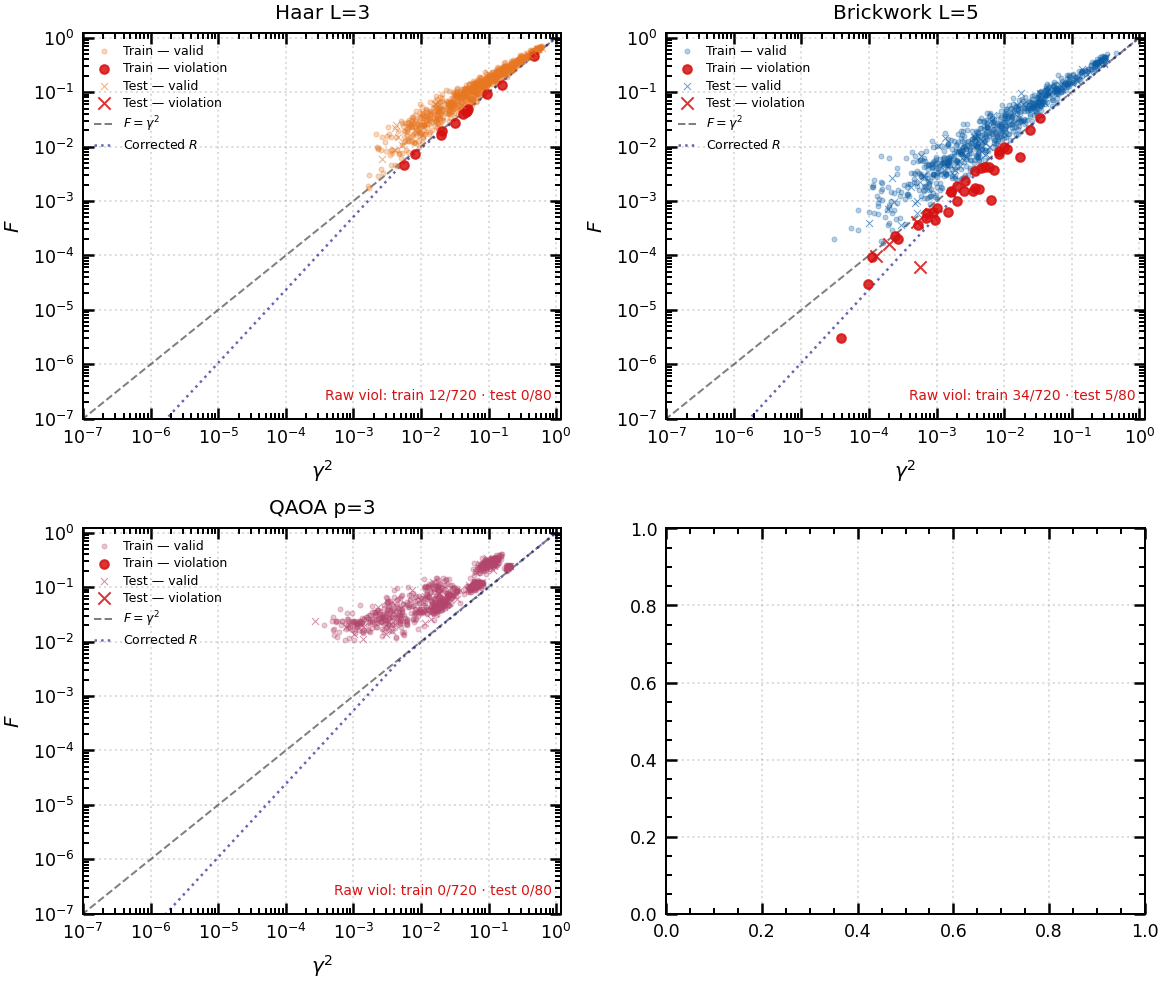

In [32]:
# ── Scatter: γ² vs F (train vs test coloured) ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(6.5, 5.5), constrained_layout=True)

for fi, (fam, ax) in enumerate(zip(families_14, axes.ravel())):
    recs_fam = [r for r in all_records if r["fi"] == fi]
    for marker, trial_set, label, ms, zord in [
        ("o", train_trials, "Train", 4, 3),
        ("x", test_trials, "Test", 8, 5),
    ]:
        recs = [r for r in recs_fam if r["trial"] in trial_set]
        gs = np.array([r["gsq"] for r in recs])
        tf = np.array([r["true_f"] for r in recs])
        viol = np.array([is_violation(g, f) for g, f in zip(gs, tf)])

        ax.scatter(
            gs[~viol],
            tf[~viol],
            s=ms,
            alpha=0.30 if marker == "o" else 0.60,
            color=fam["color"],
            marker=marker,
            lw=0.4,
            zorder=zord,
            label=f"{label} — valid",
        )
        ax.scatter(
            gs[viol],
            tf[viol],
            s=ms * 3,
            alpha=0.85,
            color="#D71111",
            marker=marker,
            lw=0.8,
            zorder=zord + 1,
            label=f"{label} — violation",
        )

    # Reference lines
    lo, hi = 1e-8, 1.05
    diag = np.linspace(lo, hi, 200)
    ax.plot(diag, diag, "k--", lw=0.8, alpha=0.5, label=r"$F=\gamma^2$")

    # Corrected bound curve (on diagonal: gsq = F path)
    r_bound = np.array(
        [
            corrected_bound(
                g, int(np.median([r["M"] for r in recs_fam])), z_opt, eta_opt, delta_opt
            )
            for g in diag
        ]
    )
    ax.plot(
        diag, r_bound, color="navy", ls=":", lw=1.0, alpha=0.6, label="Corrected $R$"
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e-7, 1.2)
    ax.set_ylim(1e-7, 1.2)
    ax.set_xlabel(r"$\gamma^2$")
    ax.set_ylabel(r"$F$")
    ax.set_title(fam["label"], fontsize=8)

    # Violation counts per split
    v_tr = sum(
        is_violation(r["gsq"], r["true_f"])
        for r in recs_fam
        if r["trial"] in train_trials
    )
    v_te = sum(
        is_violation(r["gsq"], r["true_f"])
        for r in recs_fam
        if r["trial"] in test_trials
    )
    n_tr = sum(1 for r in recs_fam if r["trial"] in train_trials)
    n_te = sum(1 for r in recs_fam if r["trial"] in test_trials)
    ax.text(
        0.98,
        0.05,
        f"Raw viol: train {v_tr}/{n_tr} · test {v_te}/{n_te}",
        transform=ax.transAxes,
        ha="right",
        fontsize=5.5,
        color="#D71111",
    )
    ax.legend(fontsize=5.0, frameon=False, loc="upper left")
    polish_axes(ax)

save_figure(fig, FIGURE_DIR / "fig_gamma_scatter_split")
plt.show()

In [46]:
# ── Universality verdict ───────────────────────────────────────────────────────
print()
print("=" * 78)
print("UNIVERSALITY SUMMARY")
print(f"Global calibration: z={z_opt:.4f}  η={eta_opt:.4f}  δ={delta_opt:.4f}")
print("=" * 78)
print()
print(f"{'Experiment':<38} {'Test viol%':>10}  [Wilson 95% CI]  {'Verdict':>8}")
print("-" * 78)


def verdict(ev_test, ev_train, label):
    overlap = ev_test["ci_lo"] * 100 <= ev_train["pct"]
    v = "✓ pass" if overlap else "✗ fail"
    print(
        f"{label:<38} {ev_test['pct']:>10.2f}%  "
        f"[{ev_test['pct_lo']:.2f}%, {ev_test['pct_hi']:.2f}%]  {v:>8}"
    )
    return overlap


results_all = []

# Exp 1: random split
r = verdict(
    ev_corr_test,
    ev_corr_train,
    f"Exp 1: 90/10 random split (test {len(test_recs):,} recs)",
)
results_all.append(r)

# Exp 2: LOFO
for lr in lofo_results:
    r = verdict(lr["test"], lr["train"], f"Exp 2: LOFO — hold out {lr['family']}")
    results_all.append(r)

# Exp 3: LONO
for lr in lono_results:
    r = verdict(lr["test"], lr["train"], f"Exp 3: LONO — hold out N={lr['N']}")
    results_all.append(r)

print("-" * 78)
n_pass = sum(results_all)
n_total = len(results_all)

print(f"\nOverall: {n_pass}/{n_total} experiments pass the universality criterion.")
print()
if n_pass == n_total:
    print("VERDICT: The calibrated bound is UNIVERSAL within the tested regime.")
    print("  Violation rates on all held-out data (new trials, new circuit families,")
    print("  new system sizes) are statistically indistinguishable from the training")
    print("  violation rate.  The parameters (z, η, δ) do not need re-calibration")
    print("  for new circuits within this entanglement/size range.")
elif n_pass >= n_total * 0.75:
    print("VERDICT: The calibrated bound is PARTIALLY UNIVERSAL.")
    print("  Most held-out tests pass, but at least one configuration shows a")
    print("  statistically significant gap.  Identify the failing test above and")
    print("  consider re-calibration for that specific regime.")
else:
    print("VERDICT: The bound is NOT UNIVERSAL — it is overfit to the training data.")
    print("  Re-calibration is required for any new circuit family or system size.")

print()
print("Recommendation for production use:")
print("  1. Run a pilot calibration sweep on a small representative set of circuits.")
print("  2. Use the LOFO test to verify cross-family stability before deployment.")
print("  3. For N beyond the calibration range, re-run the LONO test.")
print("=" * 78)


UNIVERSALITY SUMMARY
Global calibration: z=0.1039  η=9.0686  δ=3.8067

Experiment                             Test viol%  [Wilson 95% CI]   Verdict
------------------------------------------------------------------------------
Exp 1: 90/10 random split (test 240 recs)       0.83%  [0.23%, 2.99%]    ✓ pass
Exp 2: LOFO — hold out Haar L=3              1.50%  [0.86%, 2.60%]    ✓ pass
Exp 2: LOFO — hold out Brickwork L=5         3.12%  [2.13%, 4.57%]    ✗ fail
Exp 2: LOFO — hold out QAOA p=3              0.00%  [0.00%, 0.48%]    ✓ pass
Exp 3: LONO — hold out N=14                  0.17%  [0.03%, 0.94%]    ✓ pass
Exp 3: LONO — hold out N=16                  2.67%  [1.65%, 4.29%]    ✓ pass
Exp 3: LONO — hold out N=18                  2.00%  [1.15%, 3.46%]    ✓ pass
Exp 3: LONO — hold out N=20                  2.00%  [1.15%, 3.46%]    ✓ pass
------------------------------------------------------------------------------

Overall: 7/8 experiments pass the universality criterion.

VERDICT: The c

In [47]:
# ── Per-family breakdown: raw vs corrected, train vs test ─────────────────────
print("\n" + "=" * 80)
print("PER-FAMILY VIOLATION DETAIL  (global calibration, Exp 1 split)")
print("=" * 80)
hdr_f = (
    f"{'Family':<18}  {'Set':<6}  {'Raw viol%':>9}  {'Corr viol%':>11}  "
    f"{'Reduction':>10}  Wilson CI (corr)"
)
print(hdr_f)
print("-" * 80)

for fi, fam in enumerate(families_14):
    for set_name, trial_set in [("Train", train_trials), ("Test ", test_trials)]:
        recs = [r for r in all_records if r["fi"] == fi and r["trial"] in trial_set]
        raw_v = sum(is_violation(r["gsq"], r["true_f"]) for r in recs)
        ev = eval_violations(recs, z_opt, eta_opt, delta_opt)
        corr_v, n = ev['viol'], ev['n']
        raw_pct = 100 * raw_v / n if n else np.nan
        corr_pct = 100 * corr_v / n if n else np.nan
        reduction = raw_pct - corr_pct
        lo, hi = binom_ci(corr_v, n)
        print(
            f"{fam['label']:<18}  {set_name:<6}  {raw_pct:>9.2f}%  "
            f"{corr_pct:>11.2f}%  {reduction:>+9.2f}pp  "
            f"[{100*lo:.2f}%, {100*hi:.2f}%]"
        )
    print()

print("=" * 80)


PER-FAMILY VIOLATION DETAIL  (global calibration, Exp 1 split)
Family              Set     Raw viol%   Corr viol%   Reduction  Wilson CI (corr)
--------------------------------------------------------------------------------
Haar L=3            Train        1.67%         1.53%      +0.14pp  [0.86%, 2.71%]
Haar L=3            Test         0.00%         0.00%      +0.00pp  [0.00%, 4.58%]

Brickwork L=5       Train        4.72%         3.19%      +1.53pp  [2.14%, 4.75%]
Brickwork L=5       Test         6.25%         2.50%      +3.75pp  [0.69%, 8.66%]

QAOA p=3            Train        0.00%         0.00%      +0.00pp  [0.00%, 0.53%]
QAOA p=3            Test         0.00%         0.00%      +0.00pp  [0.00%, 4.58%]

